In [1]:
import os
import xml.etree.ElementTree as ET
from PIL import Image
import pandas as pd
from tqdm import tqdm

base_dir = "../dataset_nlp/raw_himanis/guerin2/Guerin(2)"
page_dir = os.path.join(base_dir, "page")
images_out_dir = "../dataset_nlp/images_himanis"
os.makedirs(images_out_dir, exist_ok=True)

ns = {"pc": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"}

records = []
line_counter = 0
xml_files = sorted(f for f in os.listdir(page_dir) if f.endswith(".xml"))

for xml_file in tqdm(xml_files):
    root = ET.parse(os.path.join(page_dir, xml_file)).getroot()

    page_el = root.find(".//pc:Page", ns)
    image_filename = page_el.get("imageFilename")
    img_path = os.path.join(base_dir, image_filename)

    if image_filename.startswith("FRAN_0021"):
        group = "JJ207"
    elif image_filename.startswith("FRAN_0200"):
        group = "JJ210"
    else:
        group = "unknown"

    img = Image.open(img_path)
    img_w, img_h = img.size

    for text_line in root.findall(".//pc:TextLine", ns):
        unicode_el = text_line.find(".//pc:TextEquiv/pc:Unicode", ns)
        text = (unicode_el.text or "").strip() if unicode_el is not None else ""
        if not text:
            continue

        coords_el = text_line.find("pc:Coords", ns)
        points = [tuple(map(int, p.split(','))) for p in coords_el.get("points").split()]
        xs, ys = zip(*points)
        x0, y0 = max(0, min(xs)), max(0, min(ys))
        x1, y1 = min(img_w, max(xs)), min(img_h, max(ys))

        crop = img.crop((x0, y0, x1, y1))
        out_name = f"himanis_{line_counter:05d}.png"
        crop.save(os.path.join(images_out_dir, out_name))

        records.append({
            "text": text,
            "image_path": f"images_himanis/{out_name}",
            "language": "French",
            "century": "15",
            "shelfmark": f"Paris, AN, {group}",
            "project": "HIMANIS-Guerin",
            "source_corpus": "HIMANIS",
            "source_page": image_filename,
        })
        line_counter += 1

df_himanis = pd.DataFrame(records)
print(f"Lignes extraites : {len(df_himanis)}")
print(df_himanis['shelfmark'].value_counts())
df_himanis.to_csv("../dataset_nlp/himanis_clean.csv", index=False)
print("✅ himanis_clean.csv généré.")

100%|██████████████████████████████████████████████████████████████████| 284/284 [15:05<00:00,  3.19s/it]

Lignes extraites : 7698
shelfmark
Paris, AN, JJ207    3909
Paris, AN, JJ210    3789
Name: count, dtype: int64
✅ himanis_clean.csv généré.


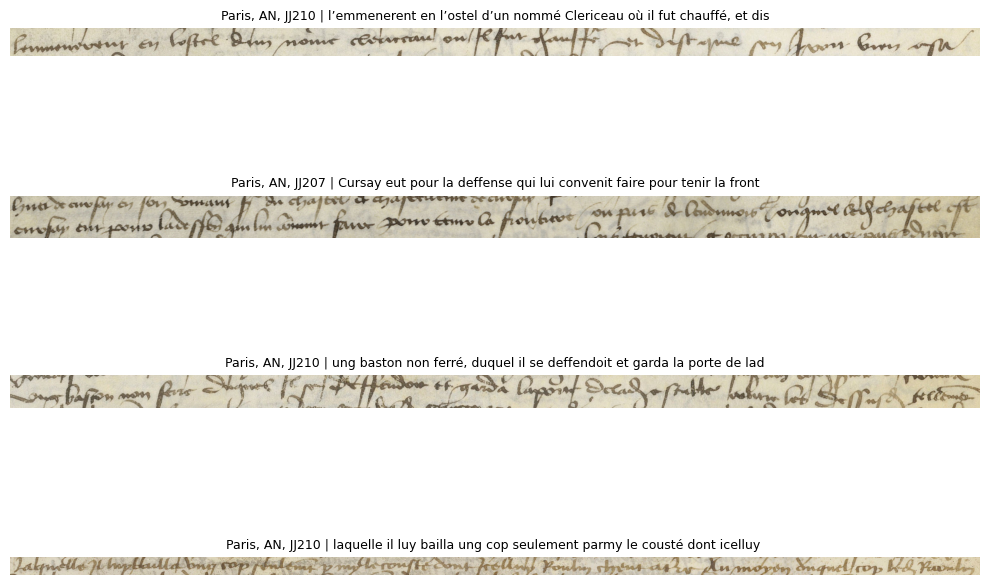

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os

samples = df_himanis.sample(4, random_state=42)
fig, axes = plt.subplots(4, 1, figsize=(10, 8))
for ax, (_, row) in zip(axes, samples.iterrows()):
    img = Image.open(os.path.join("../dataset_nlp", row['image_path']))
    ax.imshow(img)
    ax.set_title(f"{row['shelfmark']} | {row['text'][:70]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()